### 김상우 인공지능 2주차

In [7]:
# SSE
import numpy as np

def sse(y, t):
    sum_v = np.sum((y-t)**2)
    return sum_v * 0.5


In [3]:
# CEE

def cee(y, t):
    return - np.sum(t * np.log(y))

def cee(y, t):
    delta = 1e-7
    return -np.sum(t * np.log(y + delta))

In [4]:
# numerical diff

def numerical_diff (f, x):
    h = 10e-4
    return (f(x+h) - f(x-h)) / (2*h)

In [11]:
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x) # x와 shape이 같은 초기값이 0인 array 만든다.
    
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = tmp_val + h
        fxh1 = f(x)
        
        x[idx] = tmp_val - h
        fxh2 = f(x)
        
        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val
        
    return grad

# test. f(x0, x1) = x0² + x1²
def func_1(x):
    return x[0]**2 + x[1]**2

x = np.array([3.0,4.0]) # x0이 3이고 x1이 4일 때 편미분값을 구해보자

print(f"x0  x1")
print(numerical_gradient(func_1, x))

x0  x1
[6. 8.]


In [13]:
# 경사 하강법

# init_x: 초깃값, lr: 학습률, step_num: 경사법에 따른 반복횟수
def gradient_descent(f, init_x, lr=0.01, step_num = 100):
    x = init_x 
    
    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x  = x - (lr * grad)
    return x




In [ ]:
# 단순한 계층 구현하기

class MulLayer:
    def __init__(self):
        self.x = None
        self.y = None
        
    def forward(self, x, y):
        self.x  = x
        self.y = y
        out = x * y
        
        return out
    
    def backward(self, dout):
        dx = dout * self.y
        dy = dout * self.x
        return dx, dy
    
# add
class AddLayer:
    def __init__(self):
        # self.x = None
        # self.y = None
        pass
    
    def forward(self, x, y):
        # self.x = x
        # self.y = y
    
        out = x + y
        return out
    
    def backward(self, dout):
        dx = dout
        dy = dout
        return dx, dy

In [ ]:
# ex 

apple = 100
apple_num = 2
tax = 1.1

mul_apple_layer = MulLayer()
mul_tax_layer = MulLayer()

apple_price = mul_apple_layer.forward(apple, apple_num)
price = mul_tax_layer.forward(apple_price, tax)

# backward

dprice = 1
dapple_price, dtax = mul_tax_layer.backward(dprice) # 호출순서 주의
dapple, dapple_num = mul_apple_layer.backward(dapple_price)


print(dapple, dapple_num, dtax)


2.2 110.00000000000001 200


In [ ]:
# ex2

apple_price = 100
apple_num = 2

mandarin_price = 150
mandarin_num = 3

tax = 1.1


mul_apple_layer = MulLayer()
# add_apple_layer = AddLayer()

mul_mandarin_layer = MulLayer()
# add_mandarin_layer = AddLayer()

add_fruit_layer = AddLayer()
mul_tax_layer = MulLayer()


# ===================forward=========================
apple_total_price = mul_apple_layer.forward(apple_price, apple_num)
mandarin_total_price = mul_mandarin_layer.forward(mandarin_price, mandarin_num)

fruit_total_price = add_fruit_layer.forward(apple_total_price, mandarin_total_price)

price = mul_tax_layer.forward(fruit_total_price, tax)
print(f"{price:.2f}")

#===================backward=========================
dprice = 1
dfruit_price, dtax = mul_tax_layer.backward(dprice)

# fruit branch
dapple_total_price, dmandarin_total_price = add_fruit_layer.backward(dfruit_price)
dapple_price, dapple_num = mul_apple_layer.backward(dapple_total_price)
dmandarin_price, dmandarin_num = mul_mandarin_layer.backward(mandarin_total_price)

print(f"{dapple_num:.2f}", dapple_price, dmandarin_num, dmandarin_price, dtax)

715.00
110.00 2.2 67500 1350 650


In [ ]:
# ReLU

class ReLU:
    def __init__(self):
        self.mask = None
        
    def forward(self, x):
        self.mask = (x <= 0) # 0보다 작으면 0출력
        out = x.copy()
        out[self.mask] = 0
        
        return out
    
    def backward(self, dout):
        dout[self.mask] = 0
        dx = dout
        
        return dx

### 순전파 / 역전파 손계산 결과 비교해보기

In [ ]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward(x):
    h = sigmoid(x @ w1 + b1)
    g = sigmoid(h @ w2 + b2)
    y = sigmoid(g @ w3 + b3)
    return h, g, y

def loss(y, t):
    return 0.5 * np.sum((y-t) ** 2)


def train(x, t, lr, step_num):
    global w1, w2, w3, b1, b2, b3

    loss_history = []

    # 학습 전 손실
    _, _, y = forward(x)
    current_loss = loss(y, t)
    loss_history.append(current_loss)

    print(f"학습 0회 손실: {current_loss:.10f}")

    for step in range(step_num):
        h, g, y = forward(x)

        # 역전파
        dy = (y - t) * y * (1 - y)
        dg = (dy @ w3.T) * g * (1 - g)
        dh = (dg @ w2.T) * h * (1 - h)

        # 경사하강법
        w3 -= lr * np.outer(g, dy)
        w2 -= lr * np.outer(h, dg)
        w1 -= lr * np.outer(x, dh)
    
        b3 -= lr * dy
        b2 -= lr * dg
        b1 -= lr * dh

        # 가중치를 수정한 후 다시 손실 계산
        _, _, y = forward(x)
        current_loss = loss(y, t)

        loss_history.append(current_loss)
        print(f"학습 {step + 1}회 손실: {current_loss:.10f}")

    return loss_history


x = np.array([1.0, 0.5, 1.0])
t = np.array([1.0, 0.0])

w1 = np.array([[0.1, 0.2, 0.1],
                [0.0, 0.1, -0.1],
                [0.2, 0.1, 0.0]])
b1 = np.array([0.0, 0.0, 0.1])

w2 = np.array([[0.1, 0.2],
                [0.2, -0.1],
                [-0.1, 0.1]])
b2 = np.array([0.0, 0.1])

w3 = np.array([[0.2, -0.1],
                [0.1, 0.2]])
b3 = np.array([0.0, 0.0])

_, _, before = forward(x)
train(x, t, lr=0.1, step_num=2)
_, _, after = forward(x)


print('\n')
print("학습 전 출력:", before)
print("학습 전 손실:", loss(before, t))
print("학습 후 출력:", after)
print("학습 후 손실:", loss(after, t))

학습 0회 손실: 0.2379744590
학습 1회 손실: 0.2332931525
학습 2회 손실: 0.2287064304


학습 전 출력: [0.54023132 0.51435559]
학습 전 손실: 0.23797445901518413
학습 후 출력: [0.54920258 0.5041771 ]
학습 후 손실: 0.22870643038761682


In [196]:
# 편향을 제거한 학습

def forward_no_bias(x):
    h = sigmoid(x @ w1)
    g = sigmoid(h @ w2)
    y = sigmoid(g @ w3)
    return h, g, y


def train_no_bias(x, t, lr, step_num):
    global w1, w2, w3

    loss_history = []

    _, _, y = forward_no_bias(x)
    loss_history.append(loss(y, t))

    print(f"학습 0회 손실: {loss_history[-1]:.10f}")

    for step in range(step_num):
        h, g, y = forward_no_bias(x)

        dy = (y - t) * y * (1 - y)
        dg = (dy @ w3.T) * g * (1 - g)
        dh = (dg @ w2.T) * h * (1 - h)

        w3 -= lr * np.outer(g, dy)
        w2 -= lr * np.outer(h, dg)
        w1 -= lr * np.outer(x, dh)

        _, _, y = forward_no_bias(x)
        current_loss = loss(y, t)
        loss_history.append(current_loss)

        print(f"학습 {step + 1}회 손실: {current_loss:.10f}")

    return loss_history

x = np.array([1.0, 0.5, 1.0])
t = np.array([1.0, 0.0])

w1 = np.array([
    [0.1, 0.2, 0.1],
    [0.0, 0.1, -0.1],
    [0.2, 0.1, 0.0]
])

w2 = np.array([
    [0.1, 0.2],
    [0.2, -0.1],
    [-0.1, 0.1]
])

w3 = np.array([
    [0.2, -0.1],
    [0.1, 0.2]
])

_, _, before = forward_no_bias(x)

loss_history = train_no_bias(
    x, t,
    lr=0.1,
    step_num=2
)

_, _, after = forward_no_bias(x)

print()
print("학습 전 출력:", before)
print("학습 전 손실:", loss(before, t))
print("학습 후 출력:", after)
print("학습 후 손실:", loss(after, t))

학습 0회 손실: 0.2375898403
학습 1회 손실: 0.2359333123
학습 2회 손실: 0.2342879516

학습 전 출력: [0.5396298  0.51306818]
학습 전 손실: 0.2375898402727285
학습 후 출력: [0.54281865 0.50947141]
학습 후 손실: 0.2342879516276949


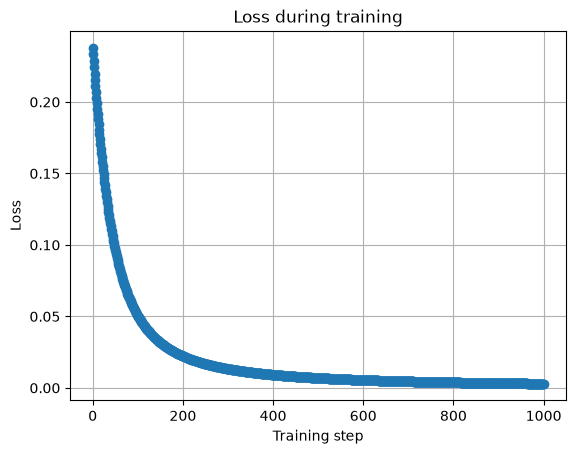

In [56]:
# 학습 횟수에 따른 고찰.


import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def forward(x):
    h = sigmoid(x @ w1 + b1)
    g = sigmoid(h @ w2 + b2)
    y = sigmoid(g @ w3 + b3)
    return h, g, y

def loss(y, t):
    return 0.5 * np.sum((y-t) ** 2)


def train(x, t, lr, step_num):
    global w1, w2, w3, b1, b2, b3

    loss_history = []

    # 학습 전 손실
    _, _, y = forward(x)
    current_loss = loss(y, t)
    loss_history.append(current_loss)

    for step in range(step_num):
        h, g, y = forward(x)

        # 역전파
        dy = (y - t) * y * (1 - y)
        dg = (dy @ w3.T) * g * (1 - g)
        dh = (dg @ w2.T) * h * (1 - h)

        # 경사하강법
        w3 -= lr * np.outer(g, dy)
        w2 -= lr * np.outer(h, dg)
        w1 -= lr * np.outer(x, dh)

        b3 -= lr * dy
        b2 -= lr * dg
        b1 -= lr * dh

        # 가중치를 수정한 후 다시 손실 계산
        _, _, y = forward(x)
        current_loss = loss(y, t)

        loss_history.append(current_loss)
        # print(f"학습 {step + 1}회 손실: {current_loss:.10f}")

    return loss_history


x = np.array([1.0, 0.5, 1.0])
t = np.array([1.0, 0.0])

w1 = np.array([[0.1, 0.2, 0.1],
                [0.0, 0.1, -0.1],
                [0.2, 0.1, 0.0]])
b1 = np.array([0.0, 0.0, 0.1])

w2 = np.array([[0.1, 0.2],
                [0.2, -0.1],
                [-0.1, 0.1]])
b2 = np.array([0.0, 0.1])

w3 = np.array([[0.2, -0.1],
                [0.1, 0.2]])
b3 = np.array([0.0, 0.0])

_, _, before = forward(x)

loss_history = train(x, t, lr=0.1, step_num=1000)

_, _, after = forward(x)

plt.plot( range(len(loss_history)), loss_history,marker="o")

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.grid()
plt.show()
